In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, multivariate_normal
from scipy.optimize import minimize

In [2]:
save_data=False

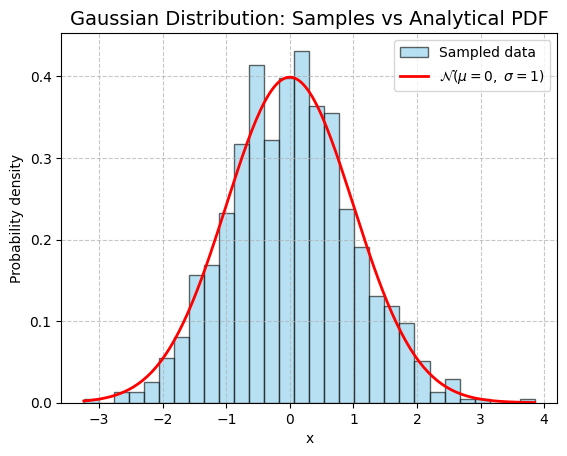

In [3]:
def gaussian_pdf(x, mu, sigma):
    """Calculate the Gaussian probability density function."""
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# 🌙 Parameters of the Gaussian distribution
mu = 0      # mean
sigma = 1   # standard deviation

# 🧮 Generate random samples
np.random.seed(42)
data = np.random.normal(mu, sigma, 1000)

# 📊 Create histogram
count, bins, ignored = plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Sampled data')

# 🧙‍♀️ Plot the corresponding analytical distribution
x = np.linspace(min(bins), max(bins), 200)

plt.plot(x, gaussian_pdf(x,mu,sigma), 'r-', linewidth=2, label=r'$\mathcal{N}(\mu=0,\ \sigma=1)$')

# ✨ Beautify the plot
plt.title('Gaussian Distribution: Samples vs Analytical PDF', fontsize=14)
plt.xlabel('x')
plt.ylabel('Probability density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

0.9352700649051168 0.06442515471159728 0.5200794456772669


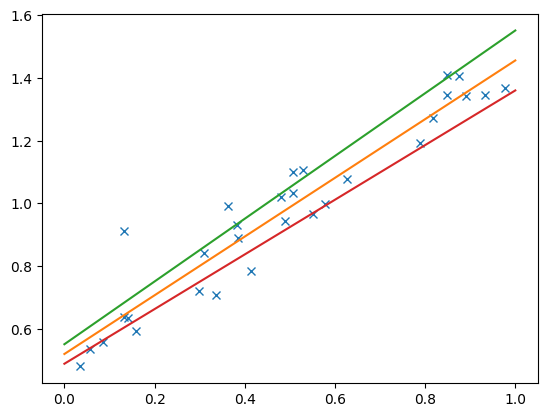

In [4]:
np.random.seed(125)
Ndata = 30
x = np.random.uniform(0,1, size=(Ndata,))

sigma = 0.1
noise = np.random.normal(0,sigma, size=(Ndata,))
omega = 1
b=0.5
y = omega*x + b + noise

barx = np.mean(x)
bary = np.mean(y)
Cxx = np.mean((x-barx)**2)
Cyx = np.mean((y-bary)*(x-barx))
omega = Cyx/Cxx
domega = sigma/np.sqrt(Ndata)/np.sqrt(Cxx)
b = bary - omega*barx
omegaplus = omega+domega
omegaminus = omega-domega
bplus = bary - omegaminus*barx
bminus = bary - omegaplus*barx
print(omega, domega, b)

plt.plot(x,y, linestyle='None', marker = 'x')
t = np.linspace(0,1,101)
plt.plot(t, omega*t+b)
plt.plot(t, omegaplus*t+bplus)
plt.plot(t, omegaminus*t+bminus)

Fitted line: y = 5.96 + 2.19 x
Estimated standard deviation of residuals: 2.58


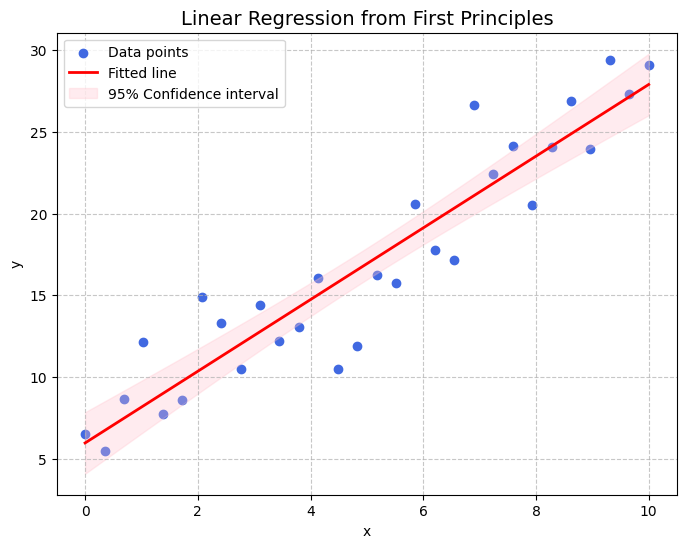

In [5]:
from scipy.stats import t

# 🌙 1. Generate synthetic data
np.random.seed(42)
N = 30
x = np.linspace(0, 10, N)
y_true = 2.5 * x + 5          # true line
sigma = 3
noise = np.random.normal(0, sigma, N)
y = y_true + noise             # noisy observations

# 🧩 2. Compute linear regression analytically
x_mean, y_mean = np.mean(x), np.mean(y)
Sxx = np.sum((x - x_mean)**2)
Sxy = np.sum((x - x_mean)*(y - y_mean))

b1 = Sxy / Sxx                # slope
b0 = y_mean - b1 * x_mean     # intercept

print(f"Fitted line: y = {b0:.2f} + {b1:.2f} x")

# 🪶 3. Compute predicted values and residuals
y_pred = b0 + b1 * x
residuals = y - y_pred
s2 = np.sum(residuals**2) / (N - 2)   # variance estimate
s = np.sqrt(s2)
print(f"Estimated standard deviation of residuals: {s:.2f}")

# 🧠 4. Compute standard errors for predictions
x_range = np.linspace(min(x), max(x), 200)
y_fit = b0 + b1 * x_range

# Standard error of predicted mean
SE = s * np.sqrt(1/N + (x_range - x_mean)**2 / Sxx)

# 95% confidence interval using t-distribution
alpha = 0.05
tval = t.ppf(1 - alpha/2, N - 2)
y_upper = y_fit + tval * SE
y_lower = y_fit - tval * SE

# 🎨 5. Plot everything
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='royalblue', label='Data points')
plt.plot(x_range, y_fit, color='red', lw=2, label='Fitted line')
plt.fill_between(x_range, y_lower, y_upper, color='pink', alpha=0.3, label='95% Confidence interval')

plt.title("Linear Regression from First Principles", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
if save_data: plt.savefig('Pics/linear_regression_first_principles.pdf', transparent=True)
plt.show()


In [6]:
np.sum((y-y_true)**2)/N/sigma**2

np.float64(0.8184104381385113)

In [7]:
Ndata = 100

omega = np.array([[1, 2],[3, 4]])
b = np.array([1,-1])
ep = 0.1
x = np.random.uniform(0,1, size=(2, Ndata))
noise = np.random.normal(0,ep, size=(2, Ndata))
y = omega@x + noise + b[:,None]

barx = np.mean(x, axis=1)
bary = np.mean(y, axis=1)
Cxx = (x-barx[:,None])@(x-barx[:,None]).T/2
Cyx = (y-bary[:,None])@(x-barx[:,None]).T/2

omega1 = Cyx@np.linalg.inv(Cxx)
b1 = bary - omega1@barx
omega1, b1

(array([[0.98562982, 2.00263128],
        [2.98588037, 4.01459637]]),
 array([ 1.00577386, -0.98795346]))

Chi² thresholds (r²): [1.0001011  4.00052149 9.00162034]


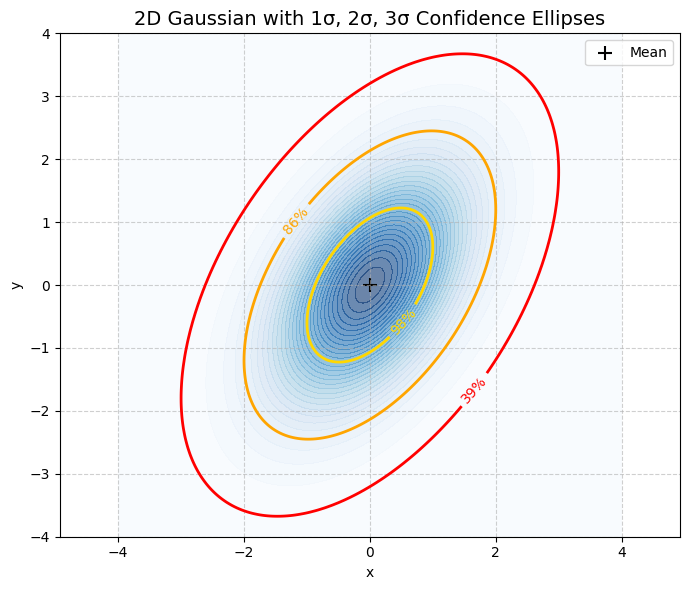

In [8]:

# 🌙 Define mean and covariance matrix
mu = np.array([0, 0])
Sigma = np.array([[1.0, 0.6],
                  [0.6, 1.5]])

# 🧮 Create a grid of (x, y) points
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# 🎲 Evaluate the 2D Gaussian PDF
rv = multivariate_normal(mu, Sigma)
Z = rv.pdf(pos)

# ⚙️ Confidence levels based on χ² quantiles for 2 DOF
levels_prob = [0.3935, 0.8647, 0.9889]   # 1σ, 2σ, 3σ equivalent
chi2_vals = chi2.ppf(levels_prob, df=2)  # χ² quantiles for df=2
print("Chi² thresholds (r²):", chi2_vals)

# 🎨 Plot the contours and the PDF
plt.figure(figsize=(7, 6))
plt.contourf(X, Y, Z, levels=30, cmap='Blues', alpha=0.6)
contours = plt.contour(X, Y, Z,
                       levels=[rv.pdf(mu) * np.exp(-q/2) for q in chi2_vals][::-1],
                       colors=['red', 'orange', 'gold'], linewidths=2)

# Label the contours
fmt = {contours.levels[i]: f"{int(levels_prob[i]*100)}%" for i in range(len(levels_prob))}
plt.clabel(contours, inline=True, fmt=fmt, fontsize=10)

# 🌟 Decorate
plt.scatter(*mu, color='black', marker='+', s=100, label='Mean')
plt.title("2D Gaussian with 1σ, 2σ, 3σ Confidence Ellipses", fontsize=14)
plt.xlabel("x")
plt.ylabel("y")
plt.axis('equal')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
if save_data: plt.savefig('Pics/2d_Gaussian_confidence_levels.pdf', transparent=True)
plt.show()


In [9]:
def fitLinear(x,y,sigma = None) :
    if len(x.shape)==1:
        x = x.reshape(1,-1)
    if len(y.shape)==1:
        y = y.reshape(1,-1)
    Ndata = x.shape[1]
    if sigma is None:
        sigma = np.ones(shape=(Ndata,))
    nrm = np.mean(1/sigma**2)
    CM = np.diag(1/sigma**2)/nrm
    xmean = (x@CM).mean(axis=1)
    ymean = (y@CM).mean(axis=1)
    Cxx = 1/Ndata*x@CM@x.T - np.tensordot(xmean, xmean, axes=0)
    Cyx = 1/Ndata*y@CM@x.T - np.tensordot(ymean, xmean, axes=0)
    omega = Cyx@np.linalg.inv(Cxx)
    return omega, ymean - omega@xmean

In [10]:
np.random.seed(123)

xdim = 2
Ndata = 100
xdata = np.random.uniform(0,1,size=(xdim, Ndata))

ydim = 2
Q = np.array([
    [1,2],
    [3,4]
])
b = np.array([5, 6])

ydata = Q@xdata + np.repeat(b, Ndata).reshape(-1,Ndata)
fitLinear(xdata,ydata)

(array([[1., 2.],
        [3., 4.]]),
 array([5., 6.]))

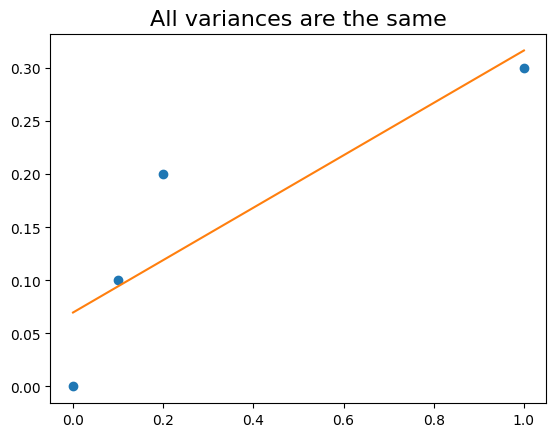

In [11]:
points = np.array([
    [0,0],
    [0.1,0.1],
    [0.2,0.2],
    [1,0.3]
])
xdata = points.T[0]
ydata = points.T[1]

omega, b = fitLinear(xdata,ydata)
omega = omega[0,0]
b = b[0]
xrng = np.linspace(np.min(xdata), np.max(xdata), 21)
yrng = omega*xrng + b

plt.plot(xdata, ydata, linestyle='None', marker='o')
plt.title('All variances are the same', fontsize=16)
plt.plot(xrng, yrng)

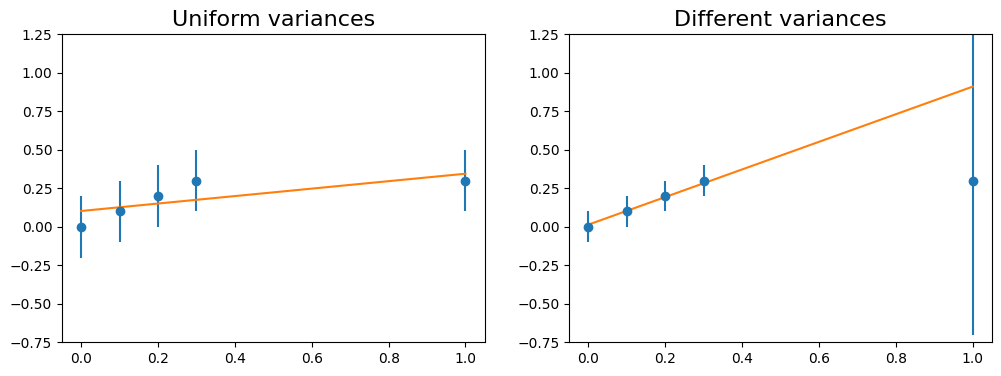

In [12]:
points = np.array([
    [0,0],
    [0.1,0.1],
    [0.2,0.2],
    [0.3,0.3],
    [1,0.3]
])
xdata = points.T[0]
ydata = points.T[1]

fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

sigmas = np.array([0.2,0.2,0.2,0.2,0.2])
omega, b = fitLinear(xdata,ydata, sigmas)
omega = omega[0,0]
b = b[0]
xrng = np.linspace(np.min(xdata), np.max(xdata), 21)
yrng = omega*xrng + b
ax[0].errorbar(xdata, ydata, yerr=sigmas, linestyle='None', marker='o')
ax[0].plot(xrng, yrng)
ax[0].set_ylim(-0.75,1.25)
ax[0].set_title("Uniform variances", fontsize=16)

sigmas = np.array([0.1,0.1,0.1,0.1,1])
omega, b = fitLinear(xdata,ydata, sigmas)
omega = omega[0,0]
b = b[0]
xrng = np.linspace(np.min(xdata), np.max(xdata), 21)
yrng = omega*xrng + b

ax[1].errorbar(xdata, ydata, yerr=sigmas, linestyle='None', marker='o')
ax[1].plot(xrng, yrng)
ax[1].set_ylim(-0.75,1.25)
ax[1].set_title("Different variances", fontsize=16)
if save_data: fig.savefig('Pics/effect_of_varainces.pdf', transparent=True)
plt.show()


In [13]:
def randomFunction(x, Nmax, modulation=0.1, damping =0.1, noise=0.1):
    while len(x)<Nmax:
        #x.append((1-modulation)*(2*x[-1]-x[-2] + np.random.normal(0,noise)))
        x.append((2-modulation)*x[-1]/(1+damping)-(1-damping)*x[-2]/(1+damping) + np.random.normal(0,noise))
    return x

def randomFunction(x, Nmax, K=0.9, noise=0.1):
    while len(x)<Nmax:
        x.append(K*(2*x[-1]-x[-2] + np.random.normal(0,noise)))
    return x

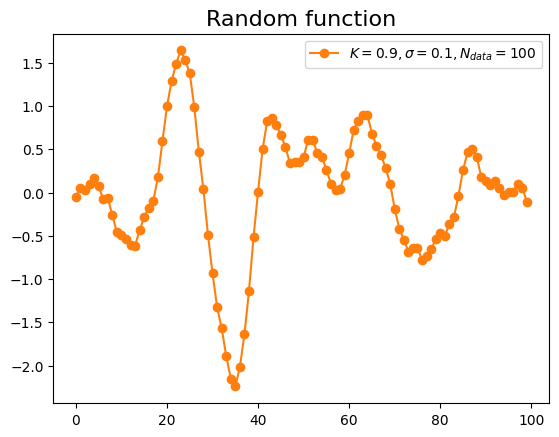

In [14]:
np.random.seed(123)
Nmax = 100
F = np.array(randomFunction([0,0.1],Nmax, K=0.9,noise=0.1))
F-=F.mean()
plt.plot(F, 'o-', color='tab:orange', label=r"$K=0.9, \sigma=0.1, N_{data}=100$")
plt.title("Random function", fontsize=16)
plt.legend()
if save_data: plt.savefig('Pics/random_function.pdf', transparent=True)

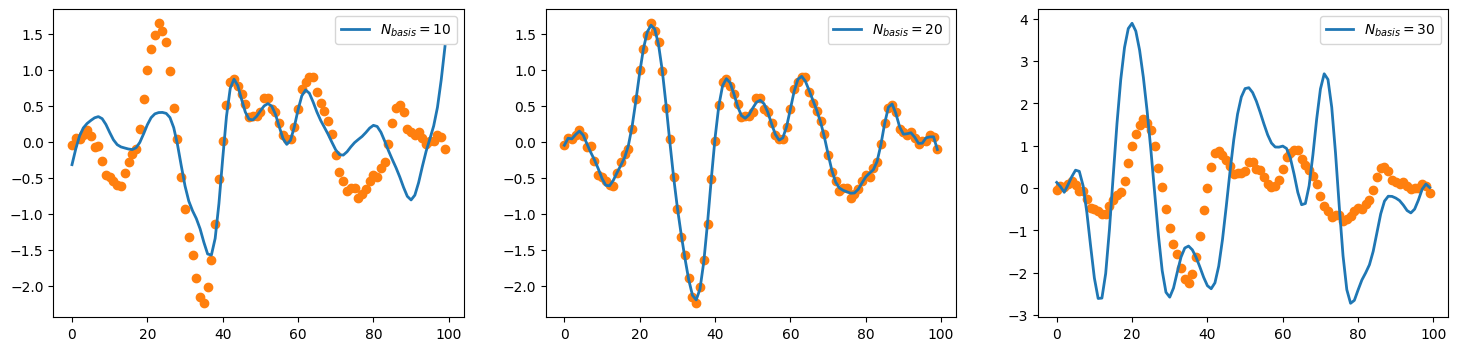

In [15]:
Nurange=[10,20,30]
lnu = len(Nurange)
fig, ax = plt.subplots(ncols=lnu, figsize=(lnu*6,4))

for i,Nnu in enumerate(Nurange):
    nus = np.linspace(1,30,Nnu) #np.random.uniform(0.5,10,size=(Nnu,))
    base1 = [[np.cos(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    base2 = [[np.sin(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    f = np.array(base1+base2).T

    ll = 0
    R = ll*np.eye(2*Nnu)

    c = np.linalg.inv(f.T@f + R)@f.T@F
    ax[i].plot(F,marker='o', color='tab:orange', linestyle='None')
    ax[i].plot(f@c, color='tab:blue', linewidth=2, label=r'$N_{basis}=$' + f'{Nnu}')
    ax[i].legend()
    #np.linalg.norm(F- f@c)
if save_data: plt.savefig('Pics/function_fit_figures.pdf', transparent=True)

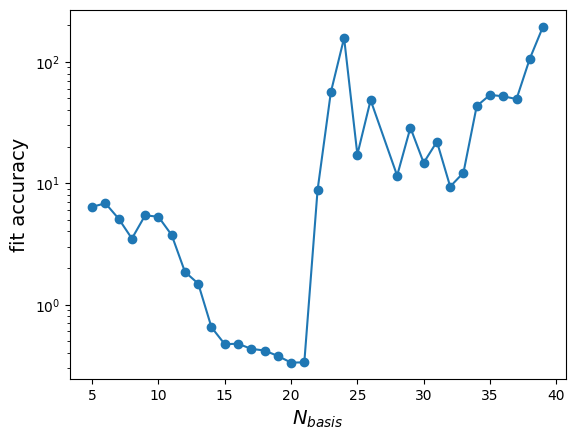

In [16]:
Nurange= list(range(5,40))
Nurange.remove(27)
result = []
for Nnu in Nurange:
    nus = np.linspace(1,30,Nnu) #np.random.uniform(0.5,10,size=(Nnu,))
    base1 = [[np.cos(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    base2 = [[np.sin(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    f = np.array(base1+base2).T

    ll = 0
    R = ll*np.eye(2*Nnu)

    c = np.linalg.inv(f.T@f + R)@f.T@F
    result.append([Nnu,np.linalg.norm(F- f@c)])
result=np.array(result).T
plt.plot(*result, 'o-')
plt.yscale('log')
plt.xlabel(r'$N_{basis}$', fontsize=14)
plt.ylabel('fit accuracy', fontsize=14)
if save_data: plt.savefig('Pics/function_fit_accuracy.pdf', transparent=True)

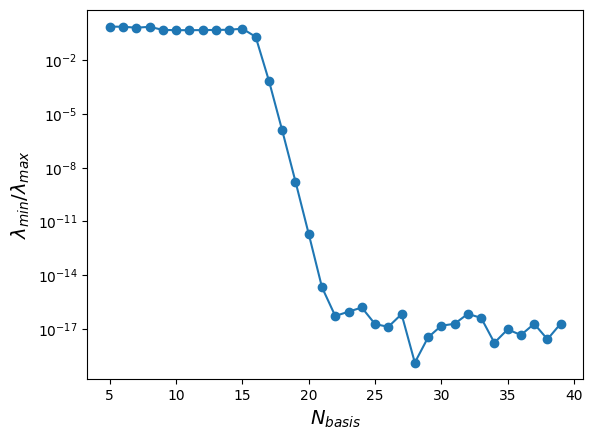

In [17]:
Nurange= list(range(5,40))
result = []
for Nnu in Nurange:
    nus = np.linspace(1,30,Nnu) #np.random.uniform(0.5,10,size=(Nnu,))
    base1 = [[np.cos(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    base2 = [[np.sin(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    f = np.array(base1+base2).T

    M = f.T@f
    lam, ev = np.linalg.eigh(M)
    result.append([Nnu, np.min(np.abs(lam))/np.max(lam)])
result = np.array(result).T
plt.plot(*result, 'o-')
plt.xlabel(r'$N_{basis}$', fontsize=14)
plt.ylabel(r'$\lambda_{min}/\lambda_{max}$', fontsize=14)
plt.yscale('log')
if save_data: plt.savefig('Pics/lambda_ratio.pdf', transparent=True)

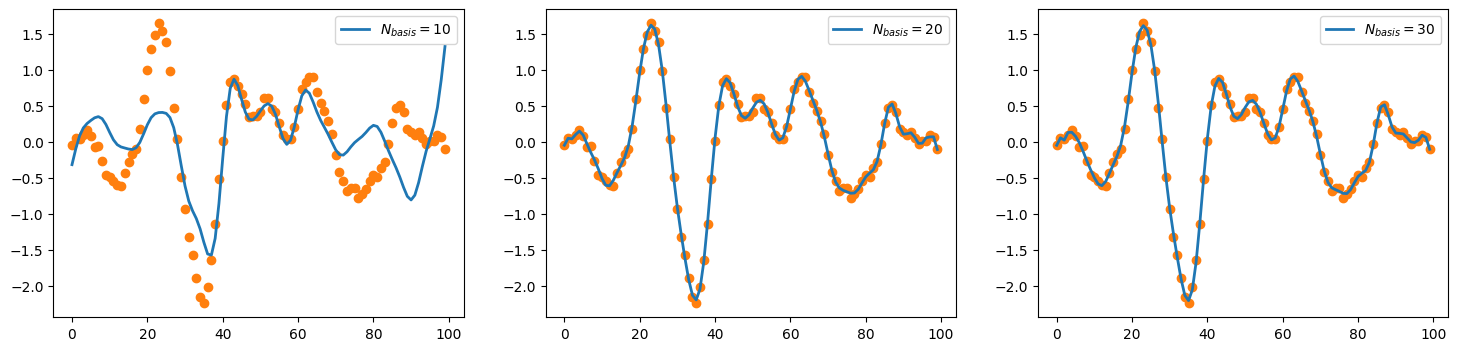

In [18]:
Nurange=[10,20,30]
lnu = len(Nurange)
fig, ax = plt.subplots(ncols=lnu, figsize=(lnu*6,4))
ep=1e-15

for i,Nnu in enumerate(Nurange):
    nus = np.linspace(1,30,Nnu) #np.random.uniform(0.5,10,size=(Nnu,))
    base1 = [[np.cos(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    base2 = [[np.sin(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    f = np.array(base1+base2).T

    ll = 0
    R = ll*np.eye(2*Nnu)

    M = f.T@f
    lam, eig = np.linalg.eigh(M)
    lam_max = np.max(lam)
    invlam = [ 1/ll if ll > ep*lam_max else 0 for ll in lam]
    Mpsinv = eig@np.diag(invlam)@eig.T

    c = Mpsinv@f.T@F

    ax[i].plot(F,marker='o', color='tab:orange', linestyle='None')
    ax[i].plot(f@c, color='tab:blue', linewidth=2, label=r'$N_{basis}=$' + f'{Nnu}')
    ax[i].legend()
    #np.linalg.norm(F- f@c)
if save_data: plt.savefig('Pics/function_fit_pseudoinverse.pdf', transparent=True)

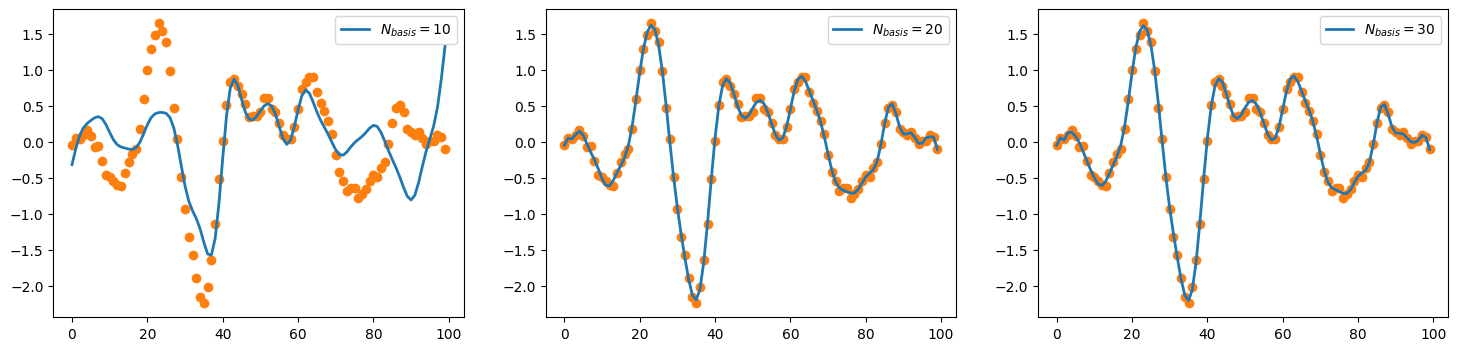

In [19]:
Nurange=[10,20,30]
lnu = len(Nurange)
fig, ax = plt.subplots(ncols=lnu, figsize=(lnu*6,4))

for i,Nnu in enumerate(Nurange):
    nus = np.linspace(1,30,Nnu) #np.random.uniform(0.5,10,size=(Nnu,))
    base1 = [[np.cos(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    base2 = [[np.sin(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    f = np.array(base1+base2).T

    c = np.linalg.pinv(f.T@f)@f.T@F

    ax[i].plot(F,marker='o', color='tab:orange', linestyle='None')
    ax[i].plot(f@c, color='tab:blue', linewidth=2, label=r'$N_{basis}=$' + f'{Nnu}')
    ax[i].legend()
    #np.linalg.norm(F- f@c)
if save_data: plt.savefig('Pics/function_fit_pseudoinverse.pdf', transparent=True)

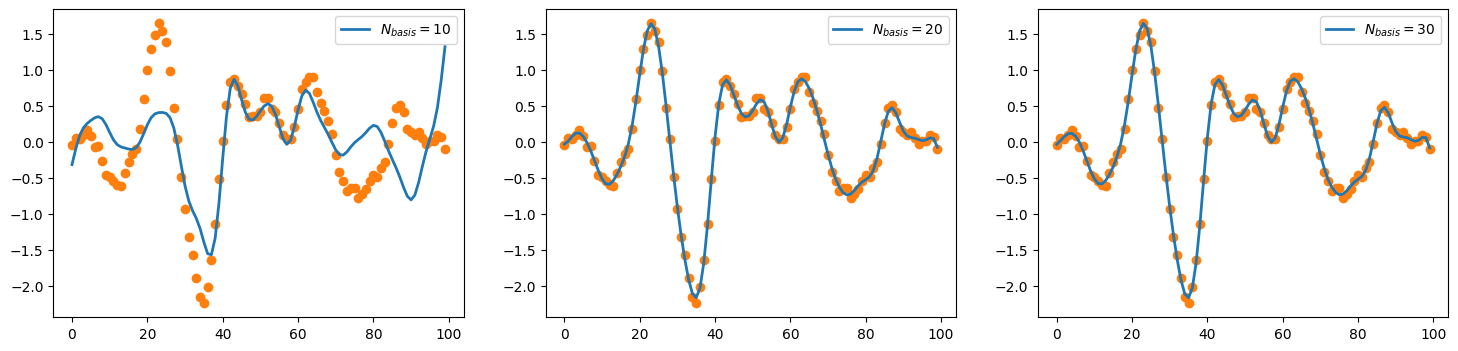

In [20]:
Nurange=[10,20,30]
lnu = len(Nurange)
fig, ax = plt.subplots(ncols=lnu, figsize=(lnu*6,4))

for i,Nnu in enumerate(Nurange):
    nus = np.linspace(1,30,Nnu) #np.random.uniform(0.5,10,size=(Nnu,))
    base1 = [[np.cos(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    base2 = [[np.sin(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    f = np.array(base1+base2).T

    ll = 0.1
    R = ll*np.eye(2*Nnu)

    c = np.linalg.inv(f.T@f + R)@f.T@F
    ax[i].plot(F,marker='o', color='tab:orange', linestyle='None')
    ax[i].plot(f@c, color='tab:blue', linewidth=2, label=r'$N_{basis}=$' + f'{Nnu}')
    ax[i].legend()
    #np.linalg.norm(F- f@c)
if save_data: plt.savefig('Pics/function_fit_L2.pdf', transparent=True)

In [21]:
csort_2 = np.sort(np.abs(c))[::-1]

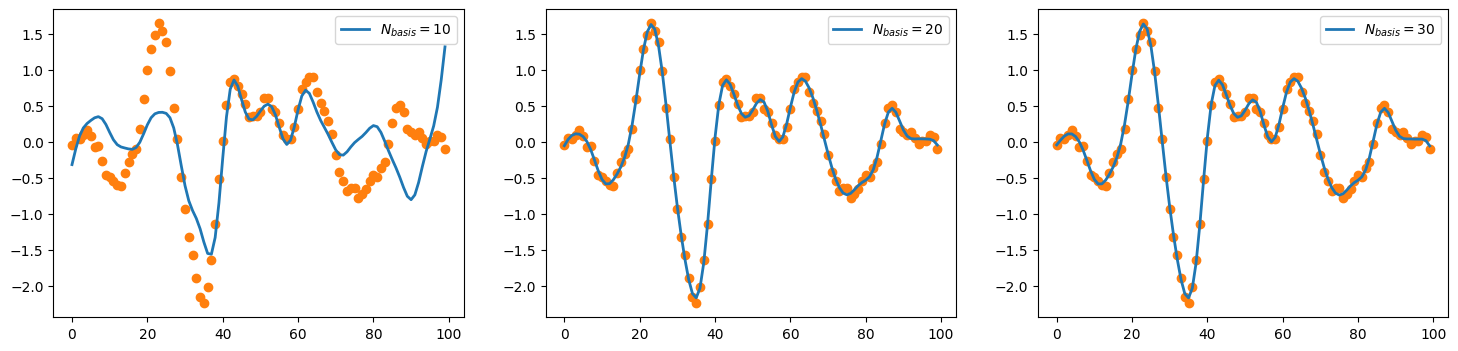

In [22]:
Nurange=[10,20,30]
lnu = len(Nurange)
fig, ax = plt.subplots(ncols=lnu, figsize=(lnu*6,4))

for i,Nnu in enumerate(Nurange):
    nus = np.linspace(1,30,Nnu) #np.random.uniform(0.5,10,size=(Nnu,))
    base1 = [[np.cos(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    base2 = [[np.sin(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    f = np.array(base1+base2).T

    beta=0.1

    def toMin(c):
        return (F-f@c).T@(F-f@c) + beta* np.linalg.norm(c, ord=1)
    c = np.ones(2*Nnu)
    result = minimize(toMin, c)
    c = result.x
    ax[i].plot(F,marker='o', color='tab:orange', linestyle='None')
    ax[i].plot(f@c, color='tab:blue', linewidth=2, label=r'$N_{basis}=$' + f'{Nnu}')
    ax[i].legend()
    #np.linalg.norm(F- f@c)
if save_data: fig.savefig('Pics/function_fit_L1.pdf', transparent=True)




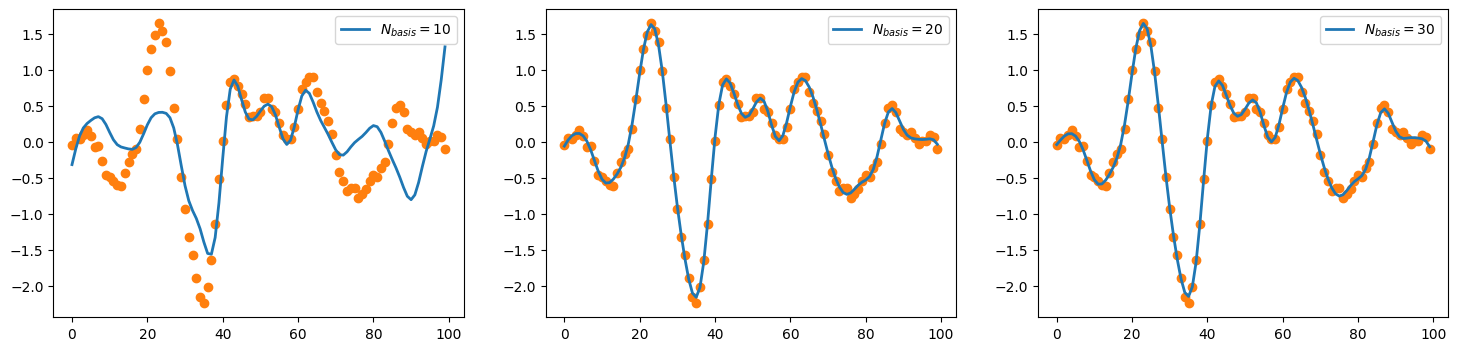

In [23]:
Nurange=[10,20,30]
lnu = len(Nurange)
fig, ax = plt.subplots(ncols=lnu, figsize=(lnu*6,4))

for i,Nnu in enumerate(Nurange):
    nus = np.linspace(1,30,Nnu) #np.random.uniform(0.5,10,size=(Nnu,))
    base1 = [[np.cos(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    base2 = [[np.sin(np.pi*nu*n/Nmax) for n in range(Nmax)] for nu in nus]
    f = np.array(base1+base2).T

    beta=0.1

    def toMin(c):
        return (F-f@c).T@(F-f@c) + beta* np.linalg.norm(c, ord=1)
    c = np.ones(2*Nnu)
    result = minimize(toMin, c)
    c = [ xi if np.abs(xi)>1e-2 else 0 for xi in result.x]
    ax[i].plot(F,marker='o', color='tab:orange', linestyle='None')
    ax[i].plot(f@c, color='tab:blue', linewidth=2, label=r'$N_{basis}=$' + f'{Nnu}')
    ax[i].legend()
    #np.linalg.norm(F- f@c)
if save_data: fig.savefig('Pics/function_fit_L1_zero.pdf', transparent=True)

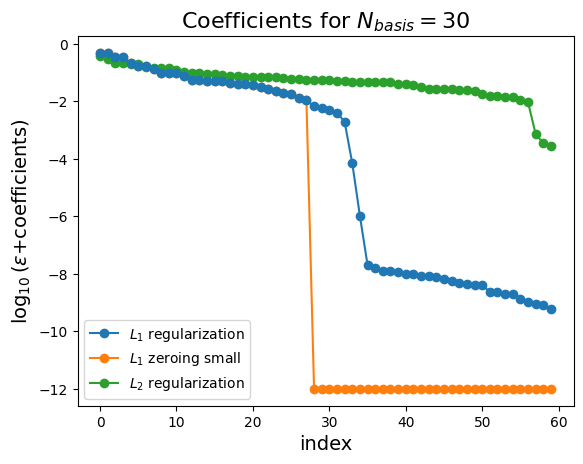

In [24]:
csort_10 = np.sort(np.abs(result.x))[::-1]
csort_1 = np.sort(np.abs(c))[::-1]
ep=1e-12
plt.plot(np.log10(ep+csort_10), marker='o', label=r'$L_1$ regularization', zorder=3)
plt.plot(np.log10(ep+csort_1), marker='o', label=r'$L_1$ zeroing small')
plt.plot(np.log10(ep+csort_2), marker='o', label=r'$L_2$ regularization')
#plt.yscale('log')
plt.ylabel(r'$\log_{10}(\varepsilon$+coefficients)', fontsize=14)
plt.xlabel('index', fontsize=14)
plt.title(r'Coefficients for $N_{basis}=30$', fontsize=16)
plt.legend()
if save_data: plt.savefig('Pics/function_fit_coefficients.pdf', transparent=True)
plt.show()


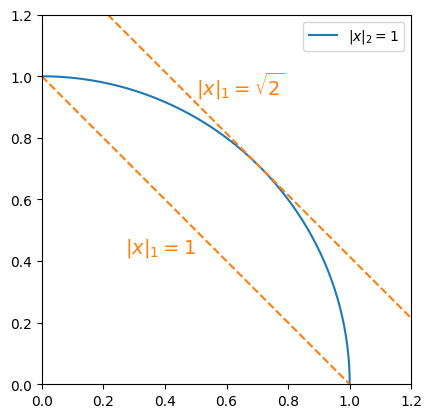

In [25]:
tu = np.linspace(0,2,101)
plt.plot(np.cos(np.pi*tu/2),np.sin(np.pi*tu/2), label=r'$|x|_2=1$')
for a in [1,np.sqrt(2)]:
    plt.plot(tu,a-tu, '--', color='tab:orange')
plt.axis('scaled')
plt.text(0.5,0.48, r'$|x|_1=1$', fontsize=14, ha='right', va='top',color='tab:orange')
plt.text(0.5,0.92, r'$|x|_1=\sqrt{2}$', fontsize=14, ha='left', va='bottom',color='tab:orange')
plt.legend()
plt.xlim(0,1.2)
plt.ylim(0,1.2)
if save_data: plt.savefig('Pics/L1_and_L2_contours.pdf', transparent=True)


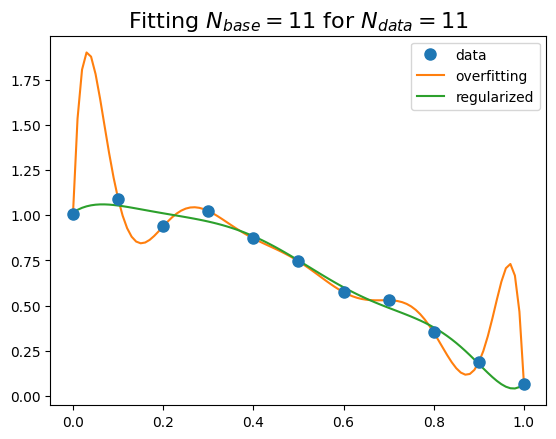

In [26]:
np.random.seed(120)
Ndata = 11
xdat = np.linspace(0,1,Ndata)
xx = np.linspace(0,1,101)
def genPol(power):
    return lambda x:x**power

F = 1-xdat**2 + np.random.normal(0,0.05,Ndata)
Nbase = 11
functs = np.array([ genPol(n) for n in range(Nbase)])
f = np.array([fi(xdat) for fi in functs]).T

ll = 1e-8
R = ll*np.eye(Nbase)

c_reg = np.linalg.inv(f.T@f)@f.T@F
c = np.linalg.inv(f.T@f + R)@f.T@F
Fapp01 = np.array([fi(xx) for fi in functs]).T@c_reg
Fapp02 = np.array([fi(xx) for fi in functs]).T@c

plt.plot(xdat, F, 'o', markersize=8, label='data', zorder=3)
plt.plot(xx, Fapp01, label='overfitting')
plt.plot(xx, Fapp02, label='regularized')
plt.title(r'Fitting $N_{base}=11$ for $N_{data}=11$', fontsize=16)
plt.legend()
if save_data: plt.savefig('Pics/interpolation_overfitting.pdf', transparent=True)


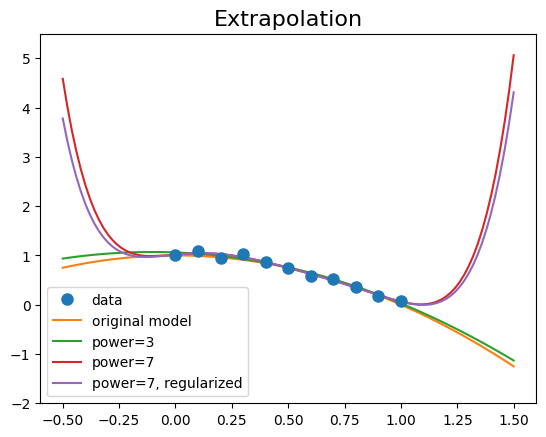

In [27]:
np.random.seed(120)
Ndata = 11
xdat = np.linspace(0,1,Ndata)
def genPol(power):
    return lambda x:x**power

xx = np.linspace(-0.5,1.5,101)


F = 1-xdat**2 + np.random.normal(0,0.05,Ndata)
Nbase = 3
functs = np.array([ genPol(n) for n in range(Nbase)])
f = np.array([fi(xdat) for fi in functs]).T
c = np.linalg.inv(f.T@f)@f.T@F
Fapp01 = np.array([fi(xx) for fi in functs]).T@c

Nbase = 7
functs = np.array([ genPol(n) for n in range(Nbase)])
f = np.array([fi(xdat) for fi in functs]).T
c = np.linalg.inv(f.T@f)@f.T@F
Fapp02 = np.array([fi(xx) for fi in functs]).T@c

Nbase = 7
functs = np.array([ genPol(n) for n in range(Nbase)])
f = np.array([fi(xdat) for fi in functs]).T
ll = 1e-8
R = ll*np.eye(Nbase)
c = np.linalg.inv(f.T@f + R)@f.T@F
Fapp03 = np.array([fi(xx) for fi in functs]).T@c



plt.plot(xdat, F, 'o', markersize=8, label='data', zorder=3)
plt.plot(xx, 1-xx**2, label='original model')
plt.plot(xx, Fapp01, label='power=3')
plt.plot(xx, Fapp02, label='power=7')
plt.plot(xx, Fapp03, label='power=7, regularized')
plt.title(r'Extrapolation', fontsize=16)
plt.ylim(-2,5.5)
plt.legend()
if save_data: plt.savefig('Pics/extrapolation.pdf', transparent=True)


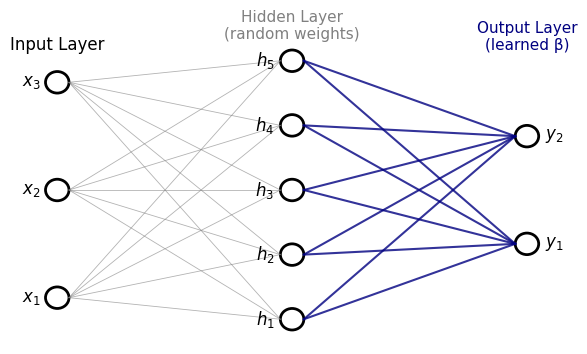

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_elm(n_input=3, n_hidden=5, n_output=2):
    fig, ax = plt.subplots(figsize=(7,4))
    
    # positions
    x_input, x_hidden, x_output = 0, 2, 4
    y_input = np.linspace(-1,1,n_input)
    y_hidden = np.linspace(-1.2,1.2,n_hidden)
    y_output = np.linspace(-0.5,0.5,n_output)

    # input nodes
    for yi in y_input:
        circ = mpatches.Circle((x_input, yi), 0.1, fill=False, lw=2)
        ax.add_patch(circ)
        ax.text(x_input-0.3, yi, f"$x_{{{int((yi - y_input[0])/(y_input[1]-y_input[0]))+1}}}$", fontsize=12, va='center')

    # hidden nodes
    for j, yh in enumerate(y_hidden):
        circ = mpatches.Circle((x_hidden, yh), 0.1, fill=False, lw=2)
        ax.add_patch(circ)
        ax.text(x_hidden-0.15, yh, f"$h_{{{j+1}}}$", fontsize=12, va='center', ha='right')
        # connections (random)
        for yi in y_input:
            ax.plot([x_input+0.1, x_hidden-0.1], [yi, yh], 'gray', lw=0.6, alpha=0.6)

    # output nodes
    for k, yo in enumerate(y_output):
        circ = mpatches.Circle((x_output, yo), 0.1, fill=False, lw=2)
        ax.add_patch(circ)
        ax.text(x_output+0.15, yo, f"$y_{{{k+1}}}$", fontsize=12, va='center', ha='left')
        # connections (learned)
        for yh in y_hidden:
            ax.plot([x_hidden+0.1, x_output-0.1], [yh, yo], 'navy', lw=1.5, alpha=0.8)

    ax.text(0,1.3,"Input Layer",ha='center',fontsize=12)
    ax.text(2,1.4,"Hidden Layer\n(random weights)",ha='center',fontsize=11,color='gray')
    ax.text(4,1.3,"Output Layer\n(learned β)",ha='center',fontsize=11,color='navy')

    ax.axis('off')
    return fig,ax

fig, ax = draw_elm()
if save_data: fig.savefig('Pics/ELM_geometry.pdf', transparent=True)
plt.show()


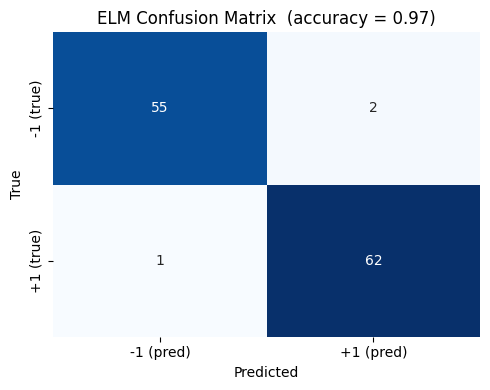

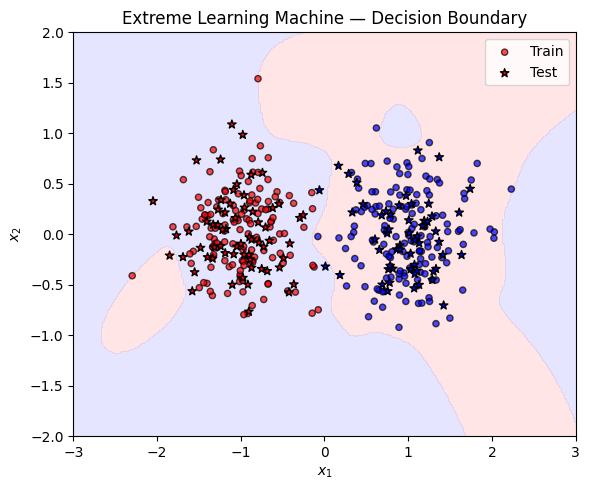

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import pinv
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import seaborn as sns

# --- 🌙 ELM class ---
class ELM:
    def __init__(self, n_hidden=50, activation=np.tanh):
        self.n_hidden = n_hidden
        self.activation = activation

    def fit(self, X, y):
        self.W = np.random.randn(X.shape[1], self.n_hidden)
        self.b = np.random.randn(self.n_hidden)
        H = self.activation(X @ self.W + self.b)
        self.beta = pinv(H) @ y

    def predict(self, X):
        H = self.activation(X @ self.W + self.b)
        return H @ self.beta

# --- 🌾 Dataset: two Gaussian blobs ---
np.random.seed(42)
N = 400
X1 = np.random.randn(N//2, 2) * 0.4 + np.array([-1, 0])
X2 = np.random.randn(N//2, 2) * 0.4 + np.array([+1, 0])
X = np.vstack([X1, X2])
y = np.hstack([np.ones(N//2), -np.ones(N//2)])

# --- ✨ Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# --- 🧠 Train ELM ---
elm = ELM(n_hidden=80)
elm.fit(X_train, y_train)

# --- 🔮 Predict ---
y_pred = np.sign(elm.predict(X_test))

# --- 📊 Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["-1 (pred)", "+1 (pred)"],
            yticklabels=["-1 (true)", "+1 (true)"])
plt.title(f"ELM Confusion Matrix  (accuracy = {acc:.2f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# --- 🌈 Optional: visualize decision boundary ---
xx, yy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-2, 2, 300))
Z = np.sign(elm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape))

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, levels=[-1,0,1], alpha=0.3, colors=['#FFAAAA','#AAAAFF'])
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='bwr', s=20, edgecolor='k', alpha=0.7, label='Train')
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='bwr', s=40, marker='*', edgecolor='k', label='Test')
plt.legend()
plt.title("Extreme Learning Machine — Decision Boundary")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.tight_layout()
if save_data: plt.savefig('Pics/ELM_classification.pdf', transparent=True)
plt.show()


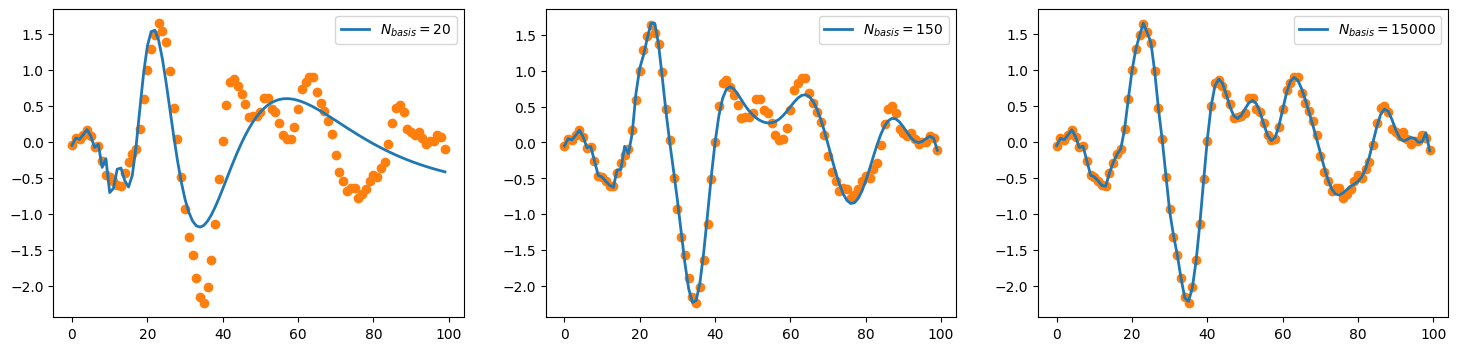

In [87]:
Nurange=[20, 150, 15000]
lnu = len(Nurange)
fig, ax = plt.subplots(ncols=lnu, figsize=(lnu*6,4))
np.random.seed(126)
for i,dims in enumerate(Nurange):
    elm = ELM(n_hidden=dims)
    elm.fit(np.arange(len(F)).reshape(-1,1),F.reshape(-1,1))
    y_pred = elm.predict(np.arange(len(F)).reshape(-1,1))
    ax[i].plot(F,marker='o', color='tab:orange', linestyle='None')
    ax[i].plot(y_pred, color='tab:blue', linewidth=2, label=r'$N_{basis}=$' + f'{dims}')
    ax[i].legend()
if save_data: fig.savefig('Pics/ELM_function_fit.pdf', transparent=True)
